# EDA - 1: Bike Details Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (update file path after upload)
df = pd.read_csv('/content/BIKE DETAILS.csv')

#### Q1. Range of selling prices

In [3]:
min_price = df['selling_price'].min()
max_price = df['selling_price'].max()
print(f"Range: {min_price} to {max_price}")

Range: 5000 to 760000


#### Q2. Median selling price

In [4]:
median_price = df['selling_price'].median()
print(f"Median selling price: {median_price}")

Median selling price: 45000.0


#### Q3. Most common seller type

In [5]:
common_seller = df['seller_type'].mode()[0]
print(f"Most common seller type: {common_seller}")

Most common seller type: Individual


#### Q4. Bikes with km driven > 50,000

In [6]:
count = len(df[df['km_driven'] > 50000])
print(f"Bikes with >50,000 km: {count}")

Bikes with >50,000 km: 170


#### Q5. Average km driven for each ownership type

In [7]:
avg_km = df.groupby('owner')['km_driven'].mean()
print(avg_km)

owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64


#### Q6. Proportion of bikes from 2015 or older

In [8]:
proportion = len(df[df['year'] <= 2015]) / len(df) * 100
print(f"Proportion: {proportion:.2f}%")

Proportion: 56.64%


#### Q7. Missing values trend

In [9]:
missing = df.isnull().sum()
print(missing[missing > 0])

ex_showroom_price    435
dtype: int64


#### Q8. Highest ex_showroom_price and bike name

In [10]:
max_price_row = df.loc[df['ex_showroom_price'].idxmax()]
print(f"Highest ex-showroom price: {max_price_row['ex_showroom_price']} for bike: {max_price_row['name']}")

Highest ex-showroom price: 1278000.0 for bike: Harley-Davidson Street Bob


#### Q9. Total bikes by seller type

In [11]:
count_by_seller = df['seller_type'].value_counts()
print(count_by_seller)

seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64


#### Q10. Relationship between selling_price and km_driven for first-owner bikes

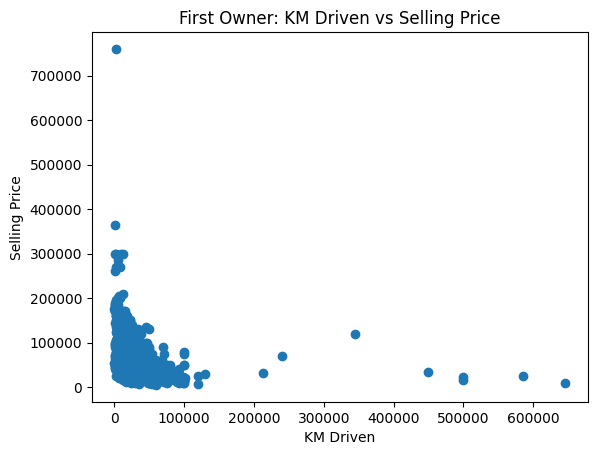

In [12]:
first_owner = df[df['owner'] == '1st owner']
plt.scatter(first_owner['km_driven'], first_owner['selling_price'])
plt.xlabel('KM Driven')
plt.ylabel('Selling Price')
plt.title('First Owner: KM Driven vs Selling Price')
plt.show()

#### Q11. Remove outliers in km_driven using IQR

In [13]:
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df_clean = df[(df['km_driven'] >= lower) & (df['km_driven'] <= upper)]
print(f"Original rows: {len(df)}, After removing outliers: {len(df_clean)}")

Original rows: 1061, After removing outliers: 1022


#### Q12. Bivariate analysis: year vs selling_price

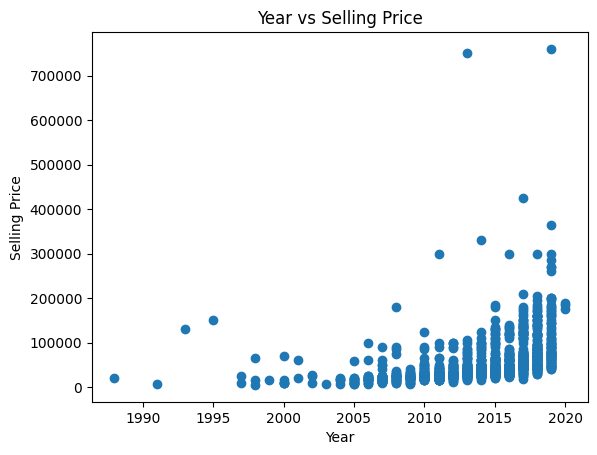

In [14]:
plt.scatter(df['year'], df['selling_price'])
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Year vs Selling Price')
plt.show()

#### Q13. Average depreciation based on bike age

In [15]:
current_year = 2026
df['age'] = current_year - df['year']
df['depreciation'] = df['ex_showroom_price'] - df['selling_price']
avg_dep = df.groupby('age')['depreciation'].mean()
print(avg_dep)

age
6    -34260.000000
7      2954.562500
8     13023.194805
9     22306.082353
10    28328.190476
11    28013.275000
12    34505.606061
13    43086.886792
14    37317.648649
15    47102.666667
16    45658.928571
17    38227.785714
18    54732.428571
19    42399.000000
20    39664.500000
21    44852.000000
22    36852.000000
23             NaN
24             NaN
25    34852.000000
26             NaN
27             NaN
28             NaN
29             NaN
31             NaN
33             NaN
35             NaN
38             NaN
Name: depreciation, dtype: float64


#### Q14. Bikes priced significantly above average for their year

In [16]:
avg_by_year = df.groupby('year')['selling_price'].mean()
df['avg_price_by_year'] = df['year'].map(avg_by_year)
above_avg = df[df['selling_price'] > df['avg_price_by_year'] * 1.2]
print(above_avg[['name', 'year', 'selling_price']])

                                      name  year  selling_price
0                Royal Enfield Classic 350  2019         175000
2      Royal Enfield Classic Gunmetal Grey  2018         150000
7     Royal Enfield Bullet 350 [2007-2011]  2008         180000
13                           Yamaha YZF R3  2019         365000
17                        Yamaha YZF R15 S  2010          40000
...                                    ...   ...            ...
984              Royal Enfield Classic 500  2014          95000
985              Royal Enfield Classic 500  2011          90000
1005                    TVS Apache RTR 160  2014          60000
1008                    Bajaj Pulsar 220 F  2012          52000
1023                Bajaj Avenger 220 dtsi  2012          45000

[233 rows x 3 columns]


#### Q15. Correlation matrix heatmap


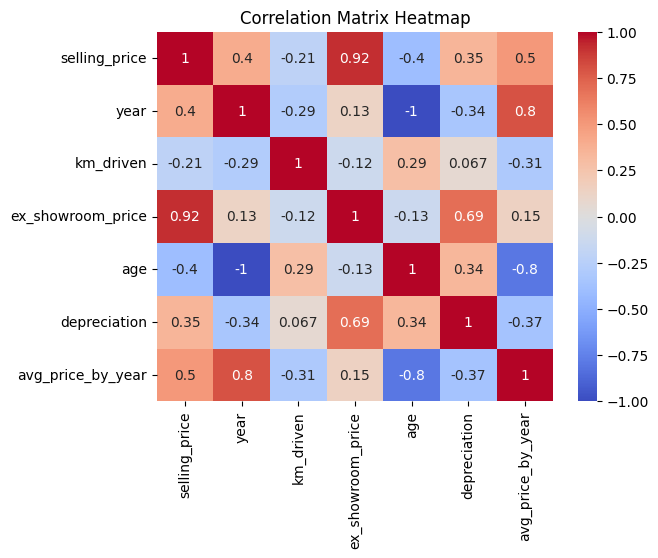

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# EDA - 2: Car Sales Dataset

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_car = pd.read_csv('/content/Car Sale.csv')

#### Q1. Average selling price for each dealer

In [21]:
print(df_car.columns.tolist())

['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region']


In [22]:
avg_by_dealer = df_car.groupby('Dealer_Name')['Price ($)'].mean()
print(avg_by_dealer)

Dealer_Name
Buddy Storbeck's Diesel Service Inc                27217.261563
C & M Motors Inc                                   28111.755200
Capitol KIA                                        28189.703822
Chrysler Plymouth                                  27555.526400
Chrysler of Tri-Cities                             28123.091054
Classic Chevy                                      28602.014446
Clay Johnson Auto Sales                            27816.027113
Diehl Motor CO Inc                                 27993.929487
Enterprise Rent A Car                              28312.580800
Gartner Buick Hyundai Saab                         28247.621019
Hatfield Volkswagen                                27853.712242
Iceberg Rentals                                    28522.958533
McKinney Dodge Chrysler Jeep                       27684.096979
Motor Vehicle Branch Office                        27956.739617
Nebo Chevrolet                                     27818.889415
New Castle Ford Lincoln Merc

#### Q2. Car brand with highest price variation

In [23]:
variation = df_car.groupby('Company')['Price ($)'].std().sort_values(ascending=False)
print(f"Highest variation: {variation.head(1)}")

Highest variation: Company
Lincoln    19658.050211
Name: Price ($), dtype: float64


#### Q3. Distribution of car prices by transmission type (boxplot)

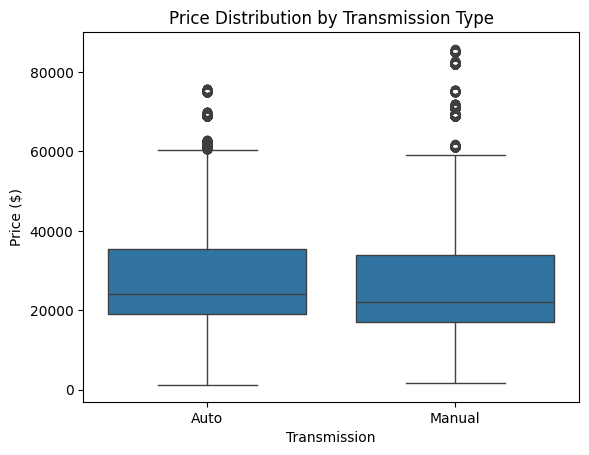

In [24]:
sns.boxplot(x='Transmission', y='Price ($)', data=df_car)
plt.title('Price Distribution by Transmission Type')
plt.show()

#### Q4. Distribution of car prices across different regions

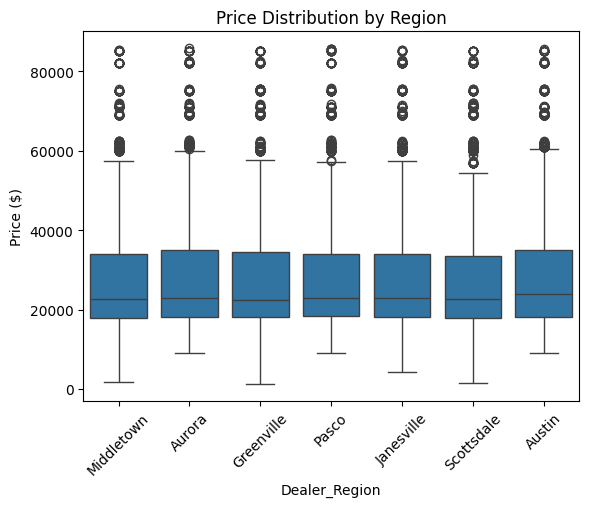

In [25]:
sns.boxplot(x='Dealer_Region', y='Price ($)', data=df_car)
plt.xticks(rotation=45)
plt.title('Price Distribution by Region')
plt.show()

#### Q5. Distribution of cars based on body styles

Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64


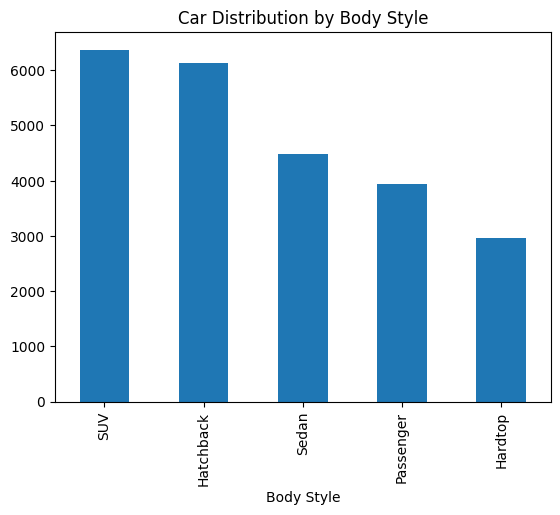

In [26]:
body_count = df_car['Body Style'].value_counts()
print(body_count)
body_count.plot(kind='bar')
plt.title('Car Distribution by Body Style')
plt.show()

#### Q6. Average selling price by customer gender and annual income

In [27]:
avg_price = df_car.groupby(['Gender', 'Annual Income'])['Price ($)'].mean()
print(avg_price)

Gender  Annual Income
Female  13500            28132.038732
        106000           46001.000000
        121000           20000.000000
        190000           19001.000000
        211000           51000.000000
                             ...     
Male    6600000          39000.000000
        6800000          15000.000000
        7650000          21000.000000
        8000000          85000.000000
        11200000         26001.000000
Name: Price ($), Length: 3442, dtype: float64


#### Q7. Price distribution and count by region

In [28]:


price_by_region = df_car.groupby('Dealer_Region')['Price ($)'].agg(['mean', 'count'])
print(price_by_region)

                       mean  count
Dealer_Region                     
Aurora         28334.626837   3130
Austin         28341.603628   4135
Greenville     28180.819054   3128
Janesville     27833.350955   3821
Middletown     27856.338875   3128
Pasco          28119.039923   3131
Scottsdale     27954.958928   3433


#### Q8. Average car price by engine size

In [29]:
avg_by_engine = df_car.groupby('Engine')['Price ($)'].mean()
print(avg_by_engine)

Engine
DoubleÂ Overhead Camshaft    28248.525972
Overhead Camshaft            27914.710631
Name: Price ($), dtype: float64


#### Q9. Car prices based on customer's annual income bracket

In [30]:
bins = [0, 30000, 60000, 90000, 120000, 150000, 200000]
labels = ['0-30k', '30-60k', '60-90k', '90-120k', '120-150k', '150k+']
df_car['Income_Bracket'] = pd.cut(df_car['Annual Income'], bins=bins, labels=labels)
avg_by_bracket = df_car.groupby('Income_Bracket')['Price ($)'].mean()
print(avg_by_bracket)

Income_Bracket
0-30k       27884.29782
30-60k              NaN
60-90k      43000.00000
90-120k     46001.00000
120-150k    17500.00000
150k+       22650.40000
Name: Price ($), dtype: float64


/tmp/ipykernel_1555/271424072.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_bracket = df_car.groupby('Income_Bracket')['Price ($)'].mean()


#### Q10. Top 5 car models with highest number of sales

In [31]:
top_models = df_car['Model'].value_counts().head(5)
print(top_models)

Model
Diamante      418
Prizm         411
Silhouette    411
Passat        391
Ram Pickup    383
Name: count, dtype: int64


#### Q11. Price vs engine size across different car colors

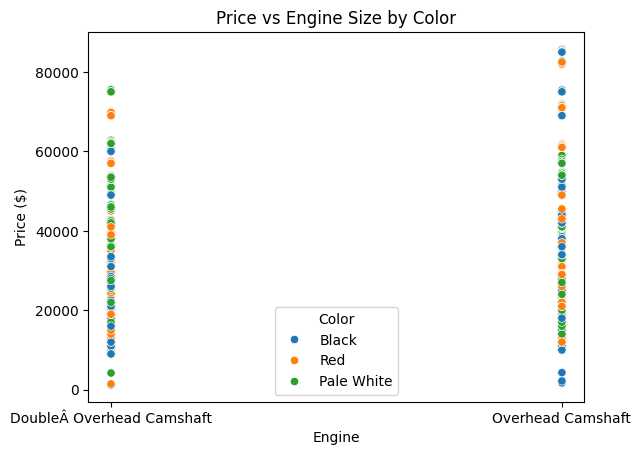

Color with highest price variation: Color
Red    15519.360962
Name: Price ($), dtype: float64


In [32]:
sns.scatterplot(x='Engine', y='Price ($)', hue='Color', data=df_car)
plt.title('Price vs Engine Size by Color')
plt.show()

# Colors with highest price variation
color_variation = df_car.groupby('Color')['Price ($)'].std().sort_values(ascending=False)
print(f"Color with highest price variation: {color_variation.head(1)}")

#### Q12. Seasonal trend in car sales based on date

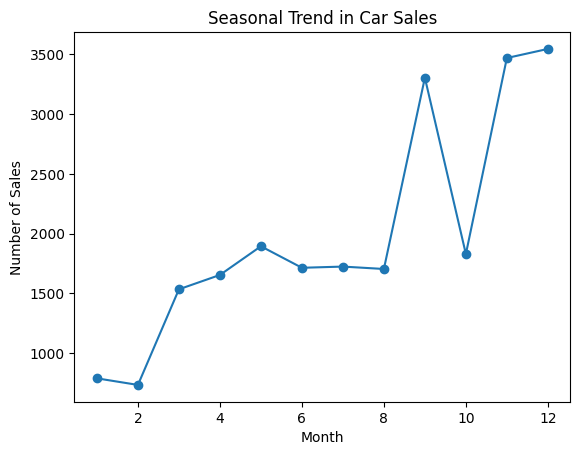

In [33]:
df_car['Date'] = pd.to_datetime(df_car['Date'])
df_car['Month'] = df_car['Date'].dt.month
monthly_sales = df_car.groupby('Month').size()
monthly_sales.plot(kind='line', marker='o')
plt.title('Seasonal Trend in Car Sales')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.show()

#### Q13. Price distribution by body style and transmission type

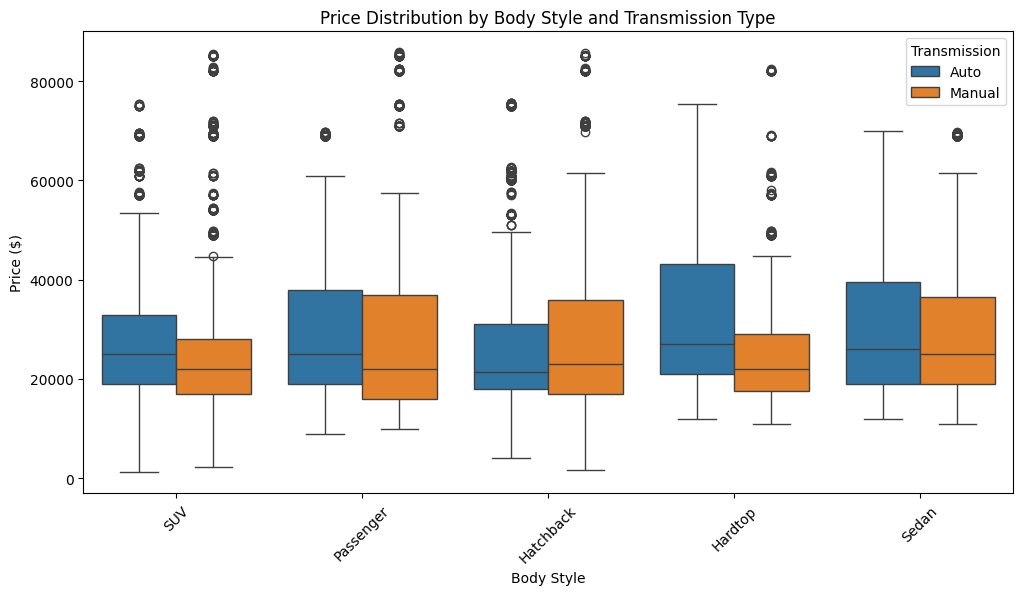

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Body Style', y='Price ($)', hue='Transmission', data=df_car)
plt.xticks(rotation=45)
plt.title('Price Distribution by Body Style and Transmission Type')
plt.show()

#### Q14. Correlation between price, engine size, and annual income

Numeric columns available: ['Annual Income', 'Price ($)', 'Phone', 'Annual Income Clean']
Correlation Matrix:
                     Annual Income  Price ($)     Phone  Annual Income Clean
Annual Income             1.000000   0.012065 -0.000351             1.000000
Price ($)                 0.012065   1.000000 -0.000493             0.012065
Phone                    -0.000351  -0.000493  1.000000            -0.000351
Annual Income Clean       1.000000   0.012065 -0.000351             1.000000


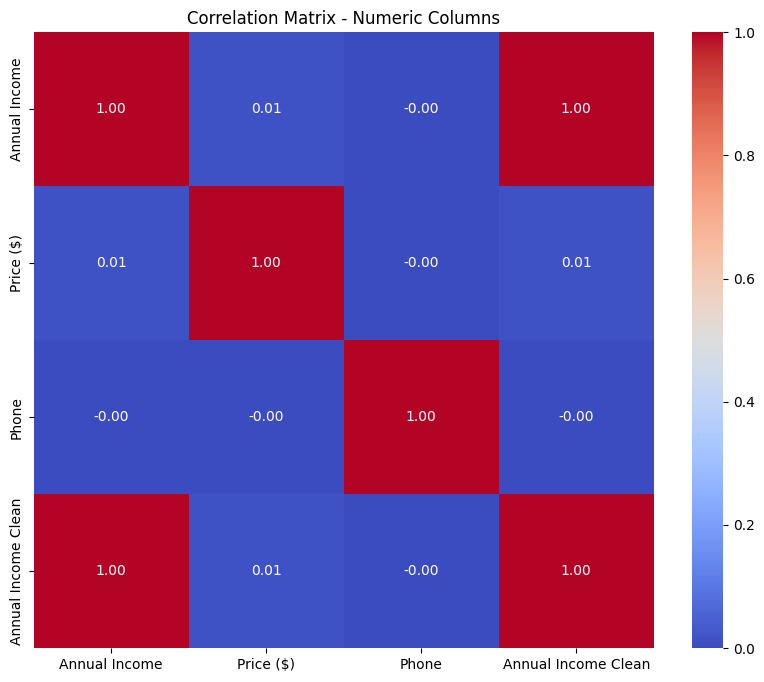

In [48]:

# Select only numeric columns automatically
numeric_cols = df_car.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns available:", numeric_cols)

# Calculate correlation only on numeric columns
corr_matrix = df_car[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Numeric Columns')
plt.show()

#### Q15. Average car price by car model and engine type python

In [49]:
avg_price = df_car.groupby(['Model', 'Engine'])['Price ($)'].mean()
print(avg_price)

Model     Engine                   
3-Sep     DoubleÂ Overhead Camshaft    37986.380117
3000GT    DoubleÂ Overhead Camshaft    22764.326923
          Overhead Camshaft            21770.659864
300M      DoubleÂ Overhead Camshaft    21394.888889
323i      DoubleÂ Overhead Camshaft    16744.632287
                                           ...     
Windstar  Overhead Camshaft            17100.272727
Wrangler  DoubleÂ Overhead Camshaft    21145.294737
          Overhead Camshaft            18742.942029
Xterra    DoubleÂ Overhead Camshaft    15940.459459
          Overhead Camshaft            31072.500000
Name: Price ($), Length: 261, dtype: float64


# EDA-3: Amazon Sales Dataset

## Load Data First

In [50]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df_amazon = pd.read_csv('amazon.csv')  # Update filename

print(df_amazon.head())
print(df_amazon.columns.tolist())

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

In [53]:
# Clean discounted_price (remove ₹ and commas)
df_amazon['discounted_price_clean'] = df_amazon['discounted_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)

# Clean actual_price (remove ₹ and commas)
df_amazon['actual_price_clean'] = df_amazon['actual_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)

# Clean rating_count (remove commas and convert to numeric)
df_amazon['rating_count_clean'] = df_amazon['rating_count'].astype(str).str.replace(',', '').astype(float)

# Clean discount_percentage (remove % sign)
df_amazon['discount_percentage_clean'] = df_amazon['discount_percentage'].astype(str).str.replace('%', '').astype(float)

print("\nData cleaned successfully!")


Data cleaned successfully!


#### Q1. Average rating for each product category

In [62]:
avg_rating = df_amazon.groupby('category')['rating_clean'].mean().sort_values(ascending=False)
print(avg_rating)

category
Computers&Accessories|Tablets                                                                                    4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters                                         4.5
Electronics|Cameras&Photography|Accessories|Film                                                                 4.5
Computers&Accessories|Components|Memory                                                                          4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                                                     4.5
                                                                                                                ... 
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                               3.6
Electronics|HomeTheater,TV&Video|Accessories|3DGlasses                                                           3.5
Computers&Accessories|Accessories&Peripherals|Audio&Vid

#### Q2. Top rating_count products by category

In [63]:
top_products = df_amazon.sort_values('rating_count_clean', ascending=False).groupby('category').head(1)
print(top_products[['category', 'product_name', 'rating_count_clean', 'rating_clean']])

                                               category  \
47    Electronics|HomeTheater,TV&Video|Accessories|C...   
400   Electronics|Headphones,Earbuds&Accessories|Hea...   
371   Electronics|Mobiles&Accessories|Smartphones&Ba...   
1028  Home&Kitchen|Kitchen&Dining|KitchenTools|Manua...   
588   Computers&Accessories|ExternalDevices&DataStor...   
...                                                 ...   
863   Computers&Accessories|Components|InternalHardD...   
1014   Computers&Accessories|Laptops|TraditionalLaptops   
557   Electronics|Mobiles&Accessories|MobileAccessor...   
269        Electronics|HomeAudio|Speakers|TowerSpeakers   
264   Electronics|HomeAudio|MediaStreamingDevices|St...   

                                           product_name  rating_count_clean  \
47    Amazon Basics High-Speed HDMI Cable, 6 Feet - ...            426973.0   
400   boAt Bassheads 100 in Ear Wired Earphones with...            363713.0   
371   Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto..

#### Q3. Distribution of discounted prices vs actual prices

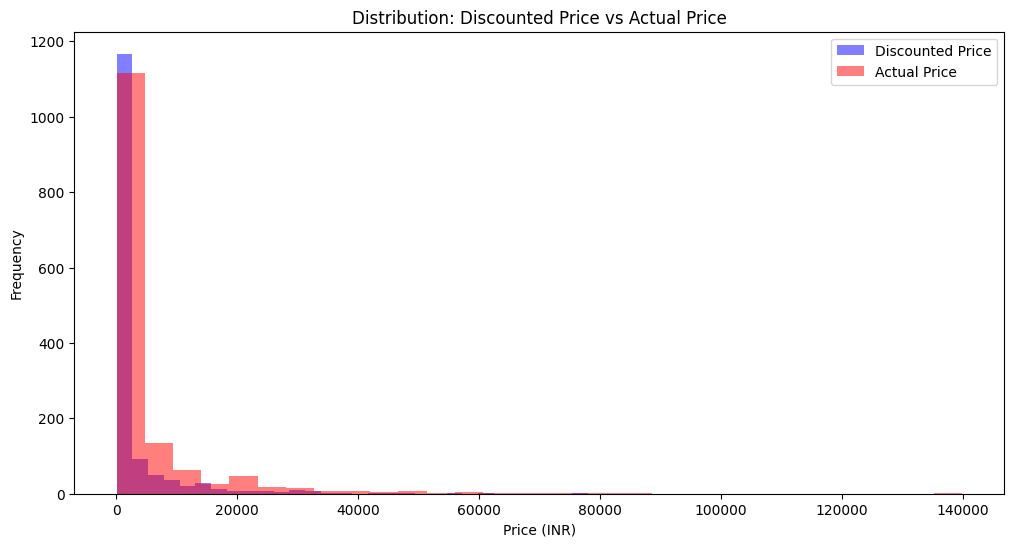

In [64]:
plt.figure(figsize=(12, 6))
plt.hist(df_amazon['discounted_price_clean'], bins=30, alpha=0.5, label='Discounted Price', color='blue')
plt.hist(df_amazon['actual_price_clean'], bins=30, alpha=0.5, label='Actual Price', color='red')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.title('Distribution: Discounted Price vs Actual Price')
plt.legend()
plt.show()

#### Q4. Average discount percentage across categories

In [65]:
avg_discount = df_amazon.groupby('category')['discount_percentage_clean'].mean().sort_values(ascending=False)
print(avg_discount)

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors                            90.0
Electronics|Headphones,Earbuds&Accessories|Earpads                                                                    90.0
Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms                                                   90.0
Electronics|Headphones,Earbuds&Accessories|Adapters                                                                   88.0
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers         87.5
                                                                                                                      ... 
OfficeProducts|OfficeElectronics|Calculators|Financial&Business                                                        0.0
OfficeProducts|OfficePaperProducts|Paper|Copy&PrintingPaper|ColouredPaper                                              0.0
OfficeP

#### Q5. Most popular product names (by rating_count)

In [66]:
popular_products = df_amazon.sort_values('rating_count_clean', ascending=False).head(10)
print(popular_products[['product_name', 'rating_count_clean', 'rating_clean']])

                                          product_name  rating_count_clean  \
47   Amazon Basics High-Speed HDMI Cable, 6 Feet - ...            426973.0   
65   Amazon Basics High-Speed HDMI Cable, 6 Feet (2...            426973.0   
12   AmazonBasics Flexible Premium HDMI Cable (Blac...            426973.0   
684  AmazonBasics Flexible Premium HDMI Cable (Blac...            426972.0   
400  boAt Bassheads 100 in Ear Wired Earphones with...            363713.0   
352  boAt Bassheads 100 in Ear Wired Earphones with...            363713.0   
584  boAt BassHeads 100 in-Ear Wired Headphones wit...            363711.0   
371  Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...            313836.0   
370  Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...            313836.0   
566  Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...            313832.0   

     rating_clean  
47            4.4  
65            4.4  
12            4.4  
684           4.4  
400           4.1  
352           4.1  
5

#### Q6. Most popular product keywords

In [67]:
all_words = ' '.join(df_amazon['product_name'].fillna('').astype(str).str.lower())
words = re.findall(r'\b\w+\b', all_words)
stopwords = {'the', 'a', 'an', 'and', 'or', 'of', 'to', 'for', 'in', 'on', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'this', 'that', 'from', 'at', 'as'}
filtered_words = [w for w in words if w not in stopwords and len(w) > 2]
common_words = Counter(filtered_words).most_common(20)
print(common_words)

[('black', 530), ('usb', 417), ('cable', 414), ('charging', 247), ('type', 243), ('fast', 212), ('smart', 175), ('white', 170), ('compatible', 146), ('data', 136), ('led', 129), ('pro', 125), ('wireless', 119), ('water', 114), ('remote', 109), ('heater', 108), ('bluetooth', 107), ('grey', 106), ('laptop', 105), ('battery', 97)]


#### Q7. Most popular product reviews (highest rating_count with good rating)

In [68]:
popular_reviews = df_amazon[df_amazon['rating_clean'] >= 4].sort_values('rating_count_clean', ascending=False).head(10)
print(popular_reviews[['product_name', 'rating_clean', 'rating_count_clean', 'review_title']])

                                          product_name  rating_clean  \
47   Amazon Basics High-Speed HDMI Cable, 6 Feet - ...           4.4   
65   Amazon Basics High-Speed HDMI Cable, 6 Feet (2...           4.4   
12   AmazonBasics Flexible Premium HDMI Cable (Blac...           4.4   
684  AmazonBasics Flexible Premium HDMI Cable (Blac...           4.4   
400  boAt Bassheads 100 in Ear Wired Earphones with...           4.1   
352  boAt Bassheads 100 in Ear Wired Earphones with...           4.1   
584  boAt BassHeads 100 in-Ear Wired Headphones wit...           4.1   
370  Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...           4.1   
371  Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...           4.1   
473  Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...           4.1   

     rating_count_clean                                       review_title  
47             426973.0  It's quite good and value for money,Works well...  
65             426973.0  It's quite good and value fo

#### Q8. Correlation between discounted_price and rating

Correlation: 0.1203


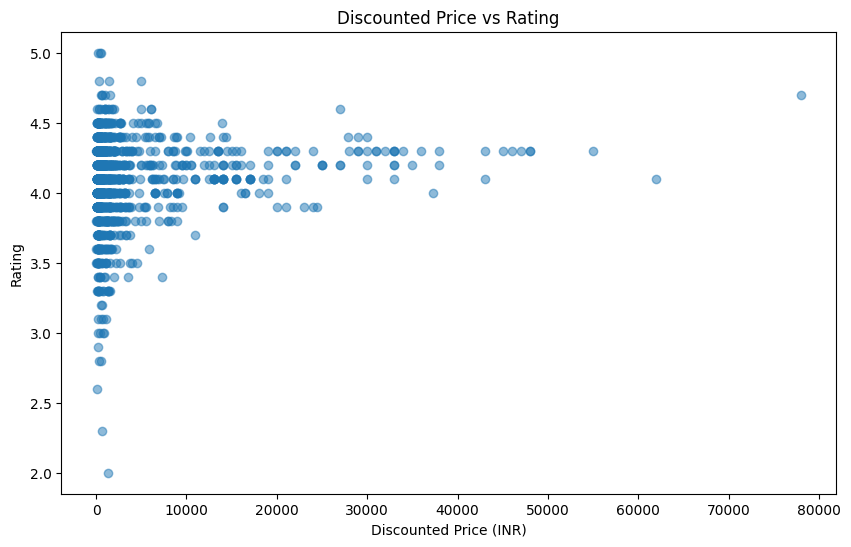

In [69]:
correlation = df_amazon['discounted_price_clean'].corr(df_amazon['rating_clean'])
print(f"Correlation: {correlation:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(df_amazon['discounted_price_clean'], df_amazon['rating_clean'], alpha=0.5)
plt.xlabel('Discounted Price (INR)')
plt.ylabel('Rating')
plt.title('Discounted Price vs Rating')
plt.show()

#### Q9. Top 5 categories based on highest ratings

In [70]:
top_categories = df_amazon.groupby('category')['rating_clean'].mean().sort_values(ascending=False).head(5)
print(top_categories)

category
Computers&Accessories|Tablets                                               4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters    4.5
Electronics|Cameras&Photography|Accessories|Film                            4.5
Computers&Accessories|Components|Memory                                     4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                4.5
Name: rating_clean, dtype: float64


#### Q10. Areas for improvement (lowest rated categories with many products)

In [71]:
category_stats = df_amazon.groupby('category').agg({'rating_clean': 'mean', 'product_name': 'count'}).rename(columns={'product_name': 'count'})
low_rated = category_stats[category_stats['rating_clean'] < 4].sort_values('rating_clean')
print(low_rated)

                                                    rating_clean  count
category                                                               
Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea&...      3.300000      1
Computers&Accessories|Accessories&Peripherals|K...      3.400000      2
Electronics|HomeTheater,TV&Video|Accessories|3D...      3.500000      1
Computers&Accessories|Accessories&Peripherals|A...      3.500000      1
Computers&Accessories|Printers,Inks&Accessories...      3.600000      2
Computers&Accessories|Accessories&Peripherals|A...      3.600000      2
Home&Kitchen|Heating,Cooling&AirQuality|RoomHea...      3.600000      2
Home&Kitchen|Kitchen&HomeAppliances|SewingMachi...      3.650000      4
Computers&Accessories|Printers,Inks&Accessories...      3.666667      3
Home&Kitchen|Kitchen&HomeAppliances|SmallKitche...      3.671429      7
Home&Kitchen|Heating,Cooling&AirQuality|RoomHea...      3.700000      2
Home&Kitchen|Kitchen&HomeAppliances|SmallKitche...      3.700000

#  EDA‑4 (Spotify Hip‑Hop)

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Load the dataset
# ============================================================
# Use the exact file name you have (spotify.csv, spotify_hiphop.csv, etc.)
df = pd.read_csv('spotify.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (440, 5)

First 5 rows:
  Artist                               Track Name  Popularity  Duration (ms)  \
0  Drake  Rich Baby Daddy (feat. Sexyy Red & SZA)          92         319191   
1  Drake                                One Dance          91         173986   
2  Drake                       IDGAF (feat. Yeat)          90         260111   
3  Drake     First Person Shooter (feat. J. Cole)          88         247444   
4  Drake            Jimmy Cooks (feat. 21 Savage)          88         218364   

                 Track ID  
0  1yeB8MUNeLo9Ek1UEpsyz6  
1  1zi7xx7UVEFkmKfv06H8x0  
2  2YSzYUF3jWqb9YP9VXmpjE  
3  7aqfrAY2p9BUSiupwk3svU  
4  3F5CgOj3wFlRv51JsHbxhe  

Column names:
['Artist', 'Track Name', 'Popularity', 'Duration (ms)', 'Track ID']


#### Q1. Read the dataframe, check null value if present then do the needful, check duplicate row, if present then do the needful

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('spotify.csv')

print("Dataset shape:", df.shape)
print("\nNull values:")
print(df.isnull().sum())

# Fill nulls if any
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicates")

print(f"\nFinal shape: {df.shape}")

Dataset shape: (440, 5)

Null values:
Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64
Removed 27 duplicates

Final shape: (413, 5)


#### Q2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram

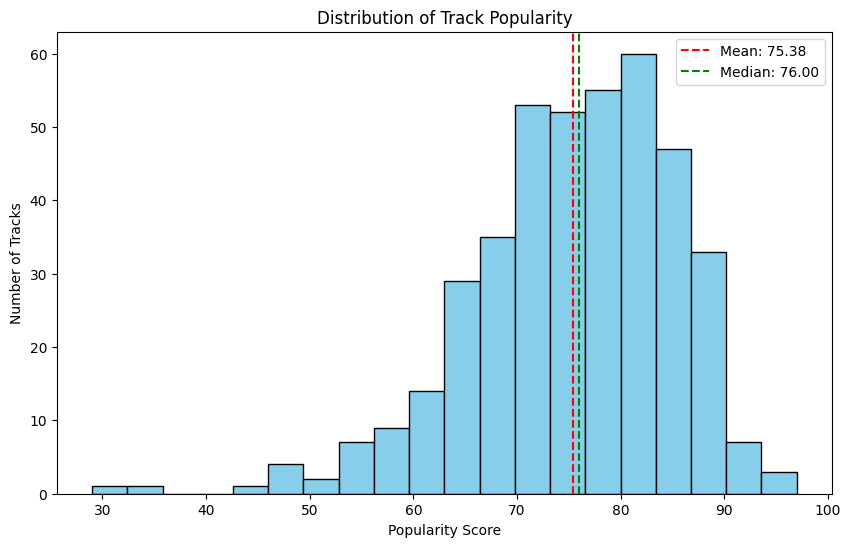

Range: 29 to 97
Mean: 75.38
Median: 76.00


In [76]:
plt.figure(figsize=(10, 6))
plt.hist(df['Popularity'], bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Tracks')
plt.title('Distribution of Track Popularity')
plt.axvline(df['Popularity'].mean(), color='red', linestyle='--', label=f'Mean: {df["Popularity"].mean():.2f}')
plt.axvline(df['Popularity'].median(), color='green', linestyle='--', label=f'Median: {df["Popularity"].median():.2f}')
plt.legend()
plt.show()

print(f"Range: {df['Popularity'].min()} to {df['Popularity'].max()}")
print(f"Mean: {df['Popularity'].mean():.2f}")
print(f"Median: {df['Popularity'].median():.2f}")

#### Q3. Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot

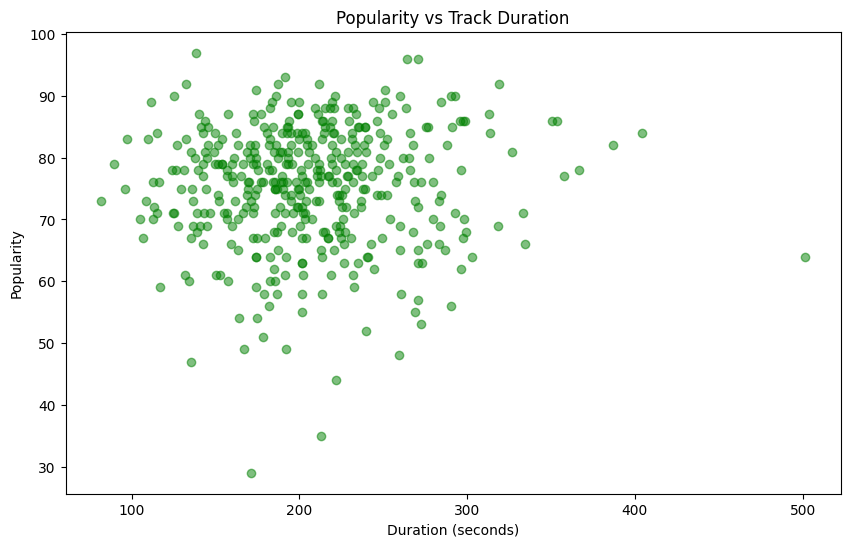

Correlation coefficient: 0.0390
Conclusion: No strong linear relationship between duration and popularity.


In [80]:
# Convert duration from ms to seconds
df['duration_sec'] = df['Duration (ms)'] / 1000

plt.figure(figsize=(10, 6))
plt.scatter(df['duration_sec'], df['Popularity'], alpha=0.5, color='green')
plt.xlabel('Duration (seconds)')
plt.ylabel('Popularity')
plt.title('Popularity vs Track Duration')
plt.show()

correlation = df['duration_sec'].corr(df['Popularity'])
print(f"Correlation coefficient: {correlation:.4f}")

if correlation < 0.3 and correlation > -0.3:
    print("Conclusion: No strong linear relationship between duration and popularity.")

#### Q4. Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot

Artist with most tracks: Drake (17 tracks)


/tmp/ipykernel_1555/426876271.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Artist', data=df, order=artist_counts.head(10).index, palette='viridis')


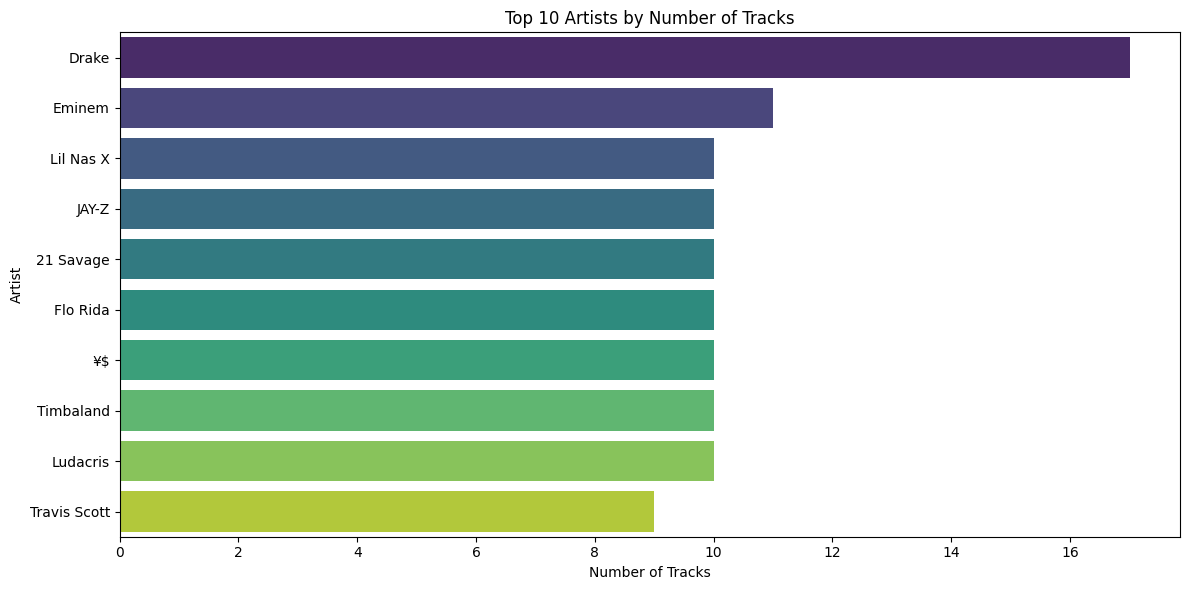

In [82]:
artist_counts = df['Artist'].value_counts()
print(f"Artist with most tracks: {artist_counts.index[0]} ({artist_counts.iloc[0]} tracks)")

plt.figure(figsize=(12, 6))
sns.countplot(y='Artist', data=df, order=artist_counts.head(10).index, palette='viridis')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.title('Top 10 Artists by Number of Tracks')
plt.tight_layout()
plt.show()

#### Q5. What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each

In [84]:
least_popular_tracks = df.sort_values(by='Popularity', ascending=True).head(5)
print("Top 5 least popular tracks:")
for index, row in least_popular_tracks.iterrows():
    print(f"- Artist: {row['Artist']}, Track: {row['Track Name']}, Popularity: {row['Popularity']}")

Top 5 least popular tracks:
- Artist: Pressa, Track: Attachments (feat. Coi Leray), Popularity: 29
- Artist: Justin Bieber, Track: Intentions, Popularity: 35
- Artist: French Montana, Track: Splash Brothers, Popularity: 44
- Artist: Lil Baby, Track: On Me - Remix, Popularity: 47
- Artist: Wyclef Jean, Track: 911 (feat. Mary J. Blige), Popularity: 48


#### Q6. Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist

Average popularity for top 5 artists (by track count):
Artist
21 Savage    83.800000
Eminem       83.636364
Drake        82.882353
JAY-Z        77.900000
Lil Nas X    75.900000
Name: Popularity, dtype: float64

Artist with highest average popularity: 21 Savage (83.80)


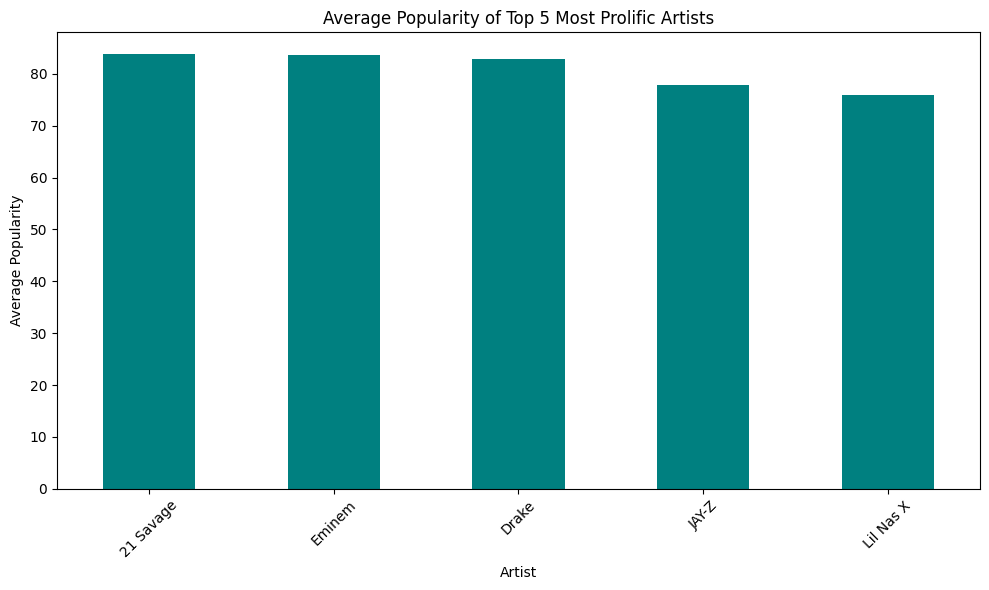

In [90]:
top5_artists = df['Artist'].value_counts().head(5).index
avg_pop = df[df['Artist'].isin(top5_artists)].groupby('Artist')['Popularity'].mean().sort_values(ascending=False)

print("Average popularity for top 5 artists (by track count):")
print(avg_pop)
print(f"\nArtist with highest average popularity: {avg_pop.index[0]} ({avg_pop.iloc[0]:.2f})")

plt.figure(figsize=(10, 6))
avg_pop.plot(kind='bar', color='teal')
plt.xlabel('Artist')
plt.ylabel('Average Popularity')
plt.title('Average Popularity of Top 5 Most Prolific Artists')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Q7. For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist

In [91]:
print("Most popular track for each top 5 artist:")
for artist in top5_artists:
    top_track = df[df['Artist'] == artist].nlargest(1, 'Popularity')
    print(f"{artist}: '{top_track.iloc[0]['Track Name']}' (Popularity: {top_track.iloc[0]['Popularity']})")

Most popular track for each top 5 artist:
Drake: 'Rich Baby Daddy (feat. Sexyy Red & SZA)' (Popularity: 92)
Eminem: 'Without Me' (Popularity: 90)
Lil Nas X: 'THATS WHAT I WANT' (Popularity: 81)
JAY-Z: 'Ni**as In Paris' (Popularity: 86)
21 Savage: 'redrum' (Popularity: 96)


#### Q8. Visualize relationships between multiple numerical variables simultaneously using a pair plot

Numerical columns: ['Popularity', 'Duration (ms)', 'duration_sec']


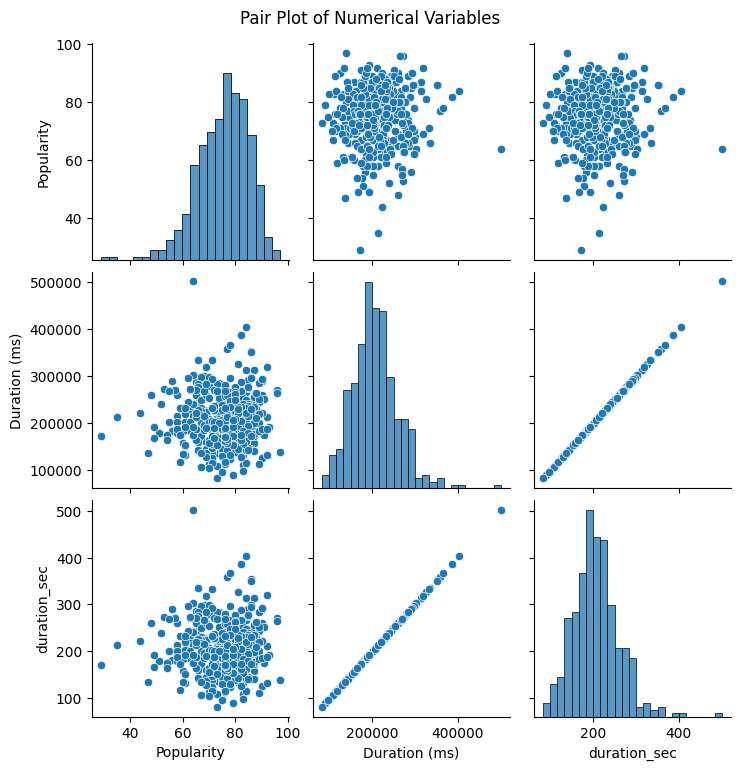

In [87]:
# Select numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {num_cols}")

if len(num_cols) >= 2:
    sns.pairplot(df[num_cols].dropna())
    plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
    plt.show()
else:
    print("Not enough numerical columns for pair plot.")

#### Q9. Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot

/tmp/ipykernel_1555/3270105740.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Artist', y='duration_sec', data=df_top10, palette='Set2')


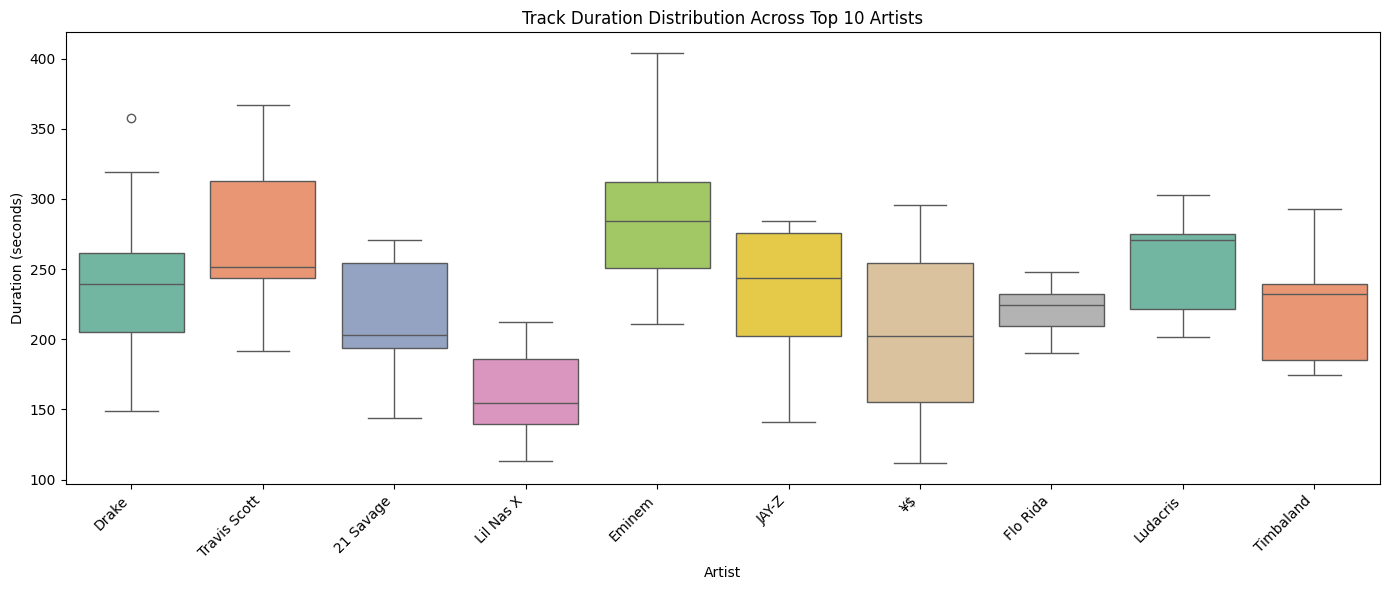


Duration statistics by artist:
                mean    std
Artist                     
21 Savage     215.71  41.24
Drake         241.58  53.99
Eminem        285.64  58.13
Flo Rida      220.68  19.00
JAY-Z         233.00  50.86
Lil Nas X     159.37  35.94
Ludacris      255.68  36.00
Timbaland     220.08  37.93
Travis Scott  270.72  60.67
¥$            202.41  65.02


In [92]:
top10_artists = df['Artist'].value_counts().head(10).index
df_top10 = df[df['Artist'].isin(top10_artists)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='Artist', y='duration_sec', data=df_top10, palette='Set2', hue='Artist', legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Artist')
plt.ylabel('Duration (seconds)')
plt.title('Track Duration Distribution Across Top 10 Artists')
plt.tight_layout()
plt.show()

print("\nDuration statistics by artist:")
print(df_top10.groupby('Artist')['duration_sec'].agg(['mean', 'std']).round(2))

#### Q10. How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot

/tmp/ipykernel_1555/2330468877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Artist', y='Popularity', data=df_top10, palette='muted')


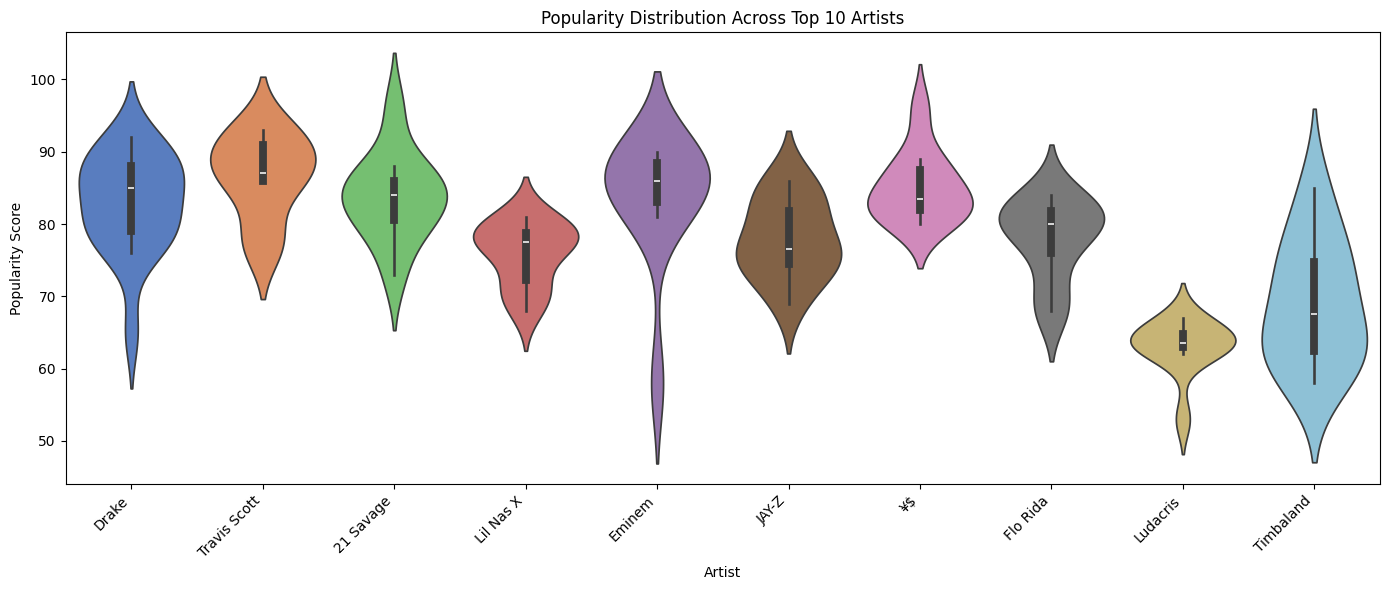

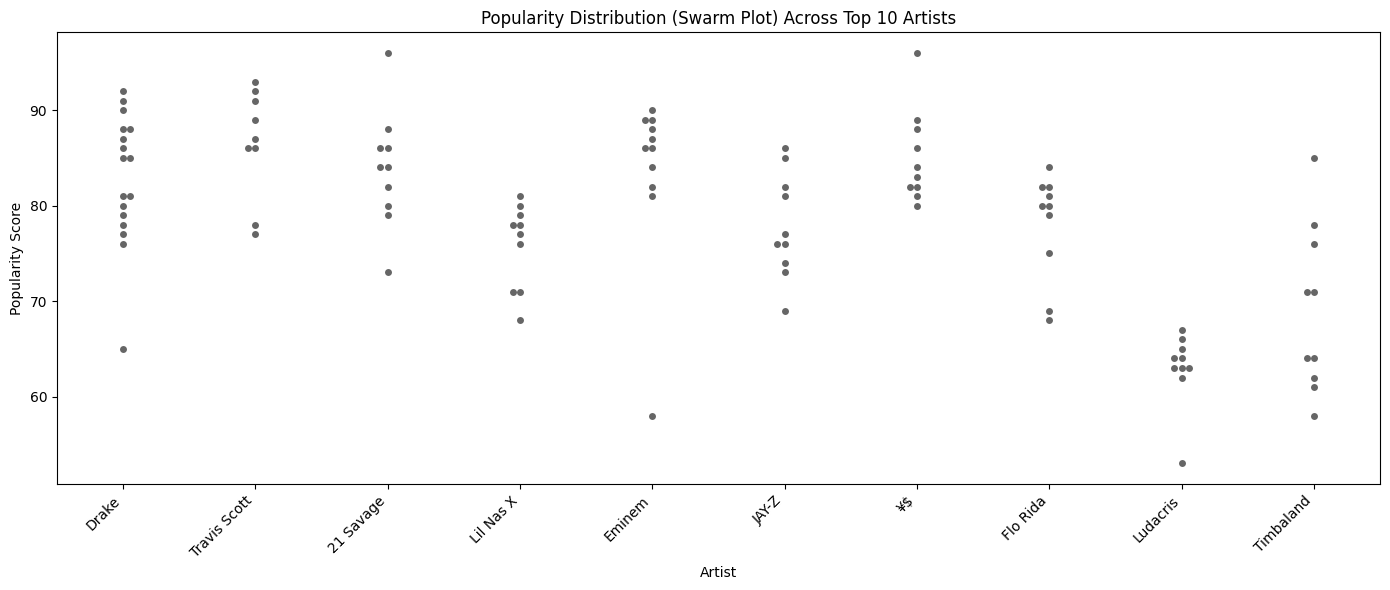


Popularity statistics by artist:
               mean   std  min  max
Artist                             
21 Savage     83.80  6.09   73   96
Drake         82.88  6.82   65   92
Eminem        83.64  8.98   58   90
Flo Rida      78.00  5.54   68   84
JAY-Z         77.90  5.47   69   86
Lil Nas X     75.90  4.38   68   81
Ludacris      63.00  3.83   53   67
Timbaland     69.00  8.68   58   85
Travis Scott  86.56  5.73   77   93
¥$            85.10  4.84   80   96


In [93]:
plt.figure(figsize=(14, 6))
sns.violinplot(x='Artist', y='Popularity', data=df_top10, palette='muted', hue='Artist', legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Artist')
plt.ylabel('Popularity Score')
plt.title('Popularity Distribution Across Top 10 Artists')
plt.tight_layout()
plt.show()

# Alternative swarm plot for individual points
plt.figure(figsize=(14, 6))
sns.swarmplot(x='Artist', y='Popularity', data=df_top10, color='black', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Artist')
plt.ylabel('Popularity Score')
plt.title('Popularity Distribution (Swarm Plot) Across Top 10 Artists')
plt.tight_layout()
plt.show()

print("\nPopularity statistics by artist:")
print(df_top10.groupby('Artist')['Popularity'].agg(['mean', 'std', 'min', 'max']).round(2))